# Hedonic Pricing

We often try to predict the price of an asset from its observable characteristics. This is generally called **hedonic pricing**: How do the unit's characteristics determine its market price?

In the lab folder, there are three options: housing prices in pierce_county_house_sales.csv, car prices in cars_hw.csv, and airbnb rental prices in airbnb_hw.csv. If you know of another suitable dataset, please feel free to use that one.

1. Clean the data and perform some EDA and visualization to get to know the data set.
2. Transform your variables --- particularly categorical ones --- for use in your regression analysis.
3. Implement an ~80/~20 train-test split. Put the test data aside.
4. Build some simple linear models that include no transformations or interactions. Fit them, and determine their RMSE and $R^2$ on the both the training and test sets. Which of your models does the best?
5. Make partial correlation plots for each of the numeric variables in your model. Do you notice any significant non-linearities?
6. Include transformations and interactions of your variables, and build a more complex model that reflects your ideas about how the features of the asset determine its value. Determine its RMSE and $R^2$ on the training and test sets. How does the more complex model your build compare to the simpler ones?
7. Summarize your results from 1 to 6. Have you learned anything about overfitting and underfitting, or model selection?
8. If you have time, use the sklearn.linear_model.Lasso to regularize your model and select the most predictive features. Which does it select? What are the RMSE and $R^2$? We'll cover the Lasso later in detail in class.

In [2]:
!git clone https://github.com/siwenliao/linear_models
%cd linear_models/lab

Cloning into 'linear_models'...
remote: Enumerating objects: 96, done.
remote: Counting objects: 100% (36/36), done.
remote: Compressing objects: 100% (24/24), done.
remote: Total 96 (delta 26), reused 12 (delta 12), pack-reused 60 (from 3)
Receiving objects: 100% (96/96), 5.09 MiB | 5.20 MiB/s, done.
Resolving deltas: 100% (29/29), done.
/content/linear_models/lab


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

Shape: (16814, 19) 

Types: sale_date                      object
sale_price                      int64
house_square_feet               int64
attic_finished_square_feet      int64
basement_square_feet            int64
attached_garage_square_feet     int64
detached_garage_square_feet     int64
fireplaces                      int64
hvac_description               object
exterior                       object
interior                       object
stories                         int64
roof_cover                     object
year_built                      int64
bedrooms                        int64
bathrooms                       int64
waterfront_type                object
view_quality                   object
utility_sewer                  object
dtype: object 

Columns: Index(['sale_date', 'sale_price', 'house_square_feet',
       'attic_finished_square_feet', 'basement_square_feet',
       'attached_garage_square_feet', 'detached_garage_square_feet',
       'fireplaces', 'hvac_description',

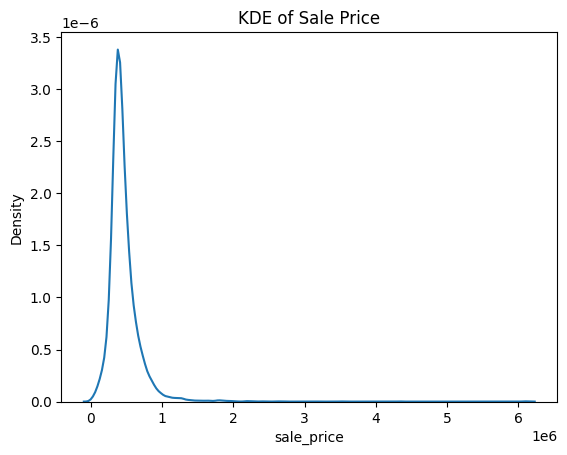

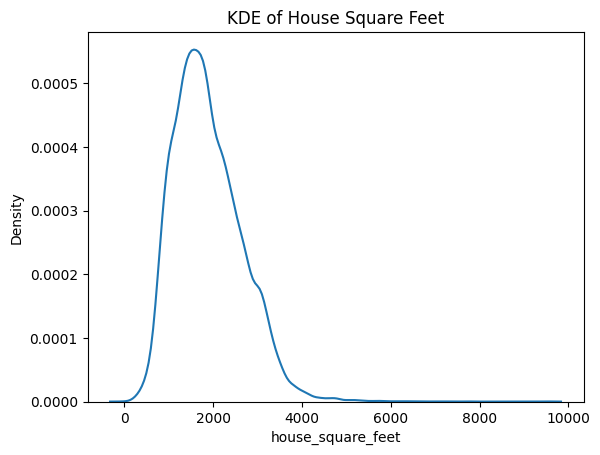

<Figure size 640x480 with 0 Axes>

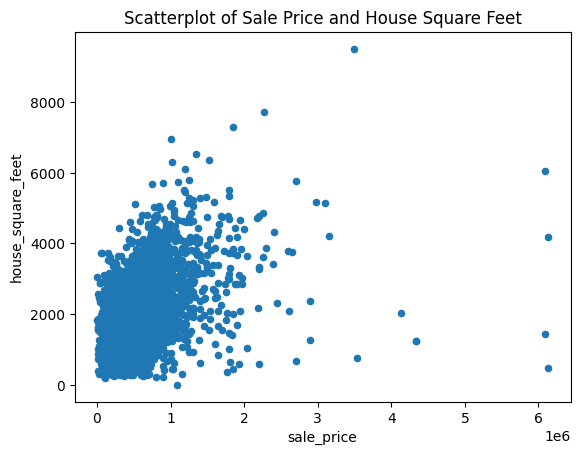

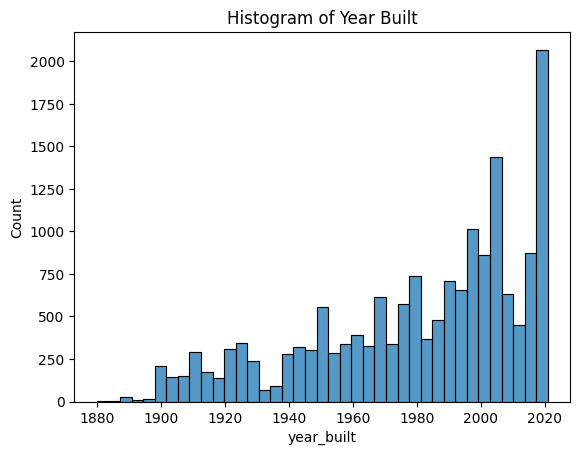

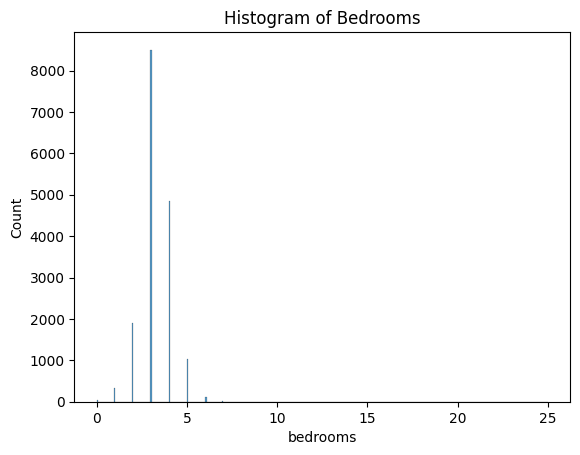

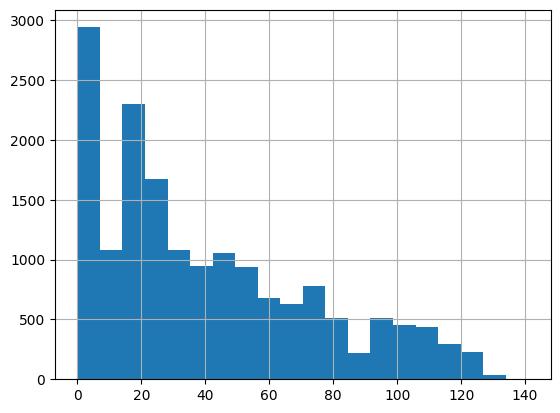

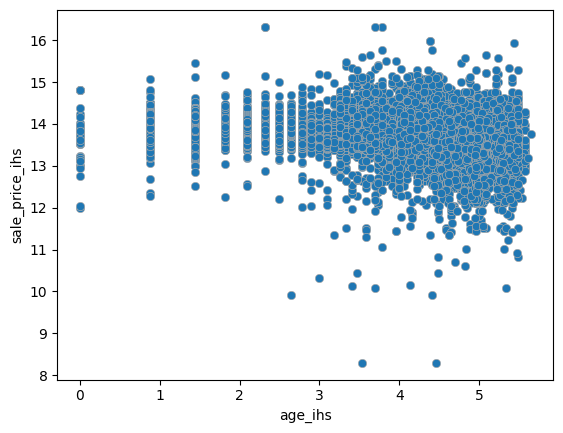

count    16814.0
mean      2020.0
std          0.0
min       2020.0
25%       2020.0
50%       2020.0
75%       2020.0
max       2020.0
Name: sale_year, dtype: float64 

count    16814.000000
mean         7.004163
std          3.296124
min          1.000000
25%          4.000000
50%          7.000000
75%         10.000000
max         12.000000
Name: sale_month, dtype: float64 



In [43]:
# 1: Clean the data and perform EDA/visualizations

df = pd.read_csv('./data/pierce_county_house_sales.csv')

print('Shape:', df.shape, '\n')
print('Types:', df.dtypes, '\n')
print('Columns:', df.columns, '\n')
print(df.describe(), '\n')
print(df.isnull().sum().sort_values(ascending=False), '\n')

df['sale_date'] = pd.to_datetime(df['sale_date'])
df['waterfront_type'] = df['waterfront_type'].fillna('None')
df['view_quality'] = df['view_quality'].fillna('None')
df['roof_cover'] = df['roof_cover'].fillna('Unknown')
df['hvac_description'] = df['hvac_description'].fillna('Unknown')
df['interior'] = df['interior'].fillna('Unknown')
df['exterior'] = df['exterior'].fillna('Unknown')

print(df['hvac_description'].unique(), '\n')
print(df['interior'].unique(), '\n')
print(df['exterior'].unique(), '\n')
print(df['roof_cover'].unique(), '\n')
print(df['utility_sewer'].unique(), '\n')

df['hvac_description']=df['hvac_description'].replace('Floor Wall Furnace', 'Floor/Wall Furnace')
df['hvac_description']=df['hvac_description'].replace('Electric', 'Electric Baseboard')

df['exterior']=df['exterior'].replace('Frame Rustic Log', 'Log')

df['utility_sewer']=df['utility_sewer'].replace('SEWER/SEPTIC NO PERC', 'SEWER/SEPTIC NO')
df['utility_sewer']=df['utility_sewer'].replace('SEWER AVAILABLE', 'SEWER/SEPTIC AVAIL')

plt.figure()
fig = sns.kdeplot(df['sale_price'])
fig.set(title='KDE of Sale Price')
plt.show()

plt.figure()
fig1 = sns.kdeplot(df['house_square_feet'])
fig1.set(title='KDE of House Square Feet')
plt.show()

plt.figure()
df.plot.scatter(x='sale_price',y='house_square_feet')
plt.title('Scatterplot of Sale Price and House Square Feet')
plt.show()

plt.figure()
fig1 = sns.histplot(df['year_built'])
fig1.set(title='Histogram of Year Built')
plt.show()

plt.figure()
fig1 = sns.histplot(df['bedrooms'])
fig1.set(title='Histogram of Bedrooms')
plt.show()

df['sale_price_ihs'] = np.arcsinh(df['sale_price'])

df['age'] = max(df['year_built'])-df['year_built']
plt.figure()
df['age'].hist(bins=20)
plt.show()

df['age_ihs'] = np.arcsinh(df['age'])
plt.figure()
sns.scatterplot(data=df,y='sale_price_ihs',x='age_ihs',edgecolor='darkgrey')
plt.show()

df['sale_year'] = df['sale_date'].dt.year
df['sale_month'] = df['sale_date'].dt.month
print(df['sale_year'].describe(), '\n')
print(df['sale_month'].describe(), '\n')


In [49]:
# 2: Transform variables for use in regression analysis

num_var = ['house_square_feet', 'attic_finished_square_feet', 'basement_square_feet',
           'attached_garage_square_feet', 'detached_garage_square_feet', 'fireplaces',
           'stories', 'age', 'bedrooms', 'bathrooms', 'sale_month']

cat_var = ['waterfront_type', 'view_quality', 'roof_cover', 'hvac_description',
           'interior', 'exterior', 'utility_sewer']

def minmax(z):
    z = (z-min(z))/(max(z)-min(z))
    return z

X_n = df.loc[:,num_var]
X_n = X_n.apply(minmax,axis=0)

dummies = pd.DataFrame([])
for var in cat_var:
    new_dummies = pd.get_dummies(df.loc[:,var], drop_first=True, dtype=int)
    dummies = pd.concat([dummies, new_dummies], axis=1, ignore_index=True)

X = pd.concat([X_n,dummies],axis=1)
X.columns = X.columns.astype(str)
y = df['sale_price_ihs']

In [50]:
# 3: Implement an 80/20 train-test split. Put the test data aside.

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,
                                                    test_size=.2,
                                                    random_state=65)

In [51]:
# 4: Simple linear models that include no transformations or interactions

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

def evaluate_model(model, X_train, X_test, y_train, y_test):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    return train_rmse, test_rmse, train_r2, test_r2

model1 = LinearRegression().fit(X_train[num_var], y_train)
m1 = evaluate_model(model1, X_train[num_var], X_test[num_var], y_train, y_test)

dummy_cols = dummies.columns.astype(str).tolist()
model2 = LinearRegression().fit(X_train[dummy_cols], y_train)
m2 = evaluate_model(model2, X_train[dummy_cols], X_test[dummy_cols], y_train, y_test)

model3 = LinearRegression().fit(X_train, y_train)
m3 = evaluate_model(model3, X_train, X_test, y_train, y_test)

results = pd.DataFrame({
    'Model': ['Model1', 'Model2', 'Model3'],
    'Train RMSE': [m1[0], m2[0], m3[0]],
    'Test RMSE': [m1[1], m2[1], m3[1]],
    'Train R2': [m1[2], m2[2], m3[2]],
    'Test R2': [m1[3], m2[3], m3[3]]
})

print(results)

    Model  Train RMSE  Test RMSE  Train R2   Test R2
0  Model1    0.323980   0.306510  0.426325  0.468449
1  Model2    0.367610   0.354959  0.261409  0.287127
2  Model3    0.304978   0.288543  0.491645  0.528939


Model 3 does the best because it has the lowest Test RMSE value and the highest Test R2 value. Model 3 is the linear model with all variables included.

Partial R^2:  0.1041038399325519


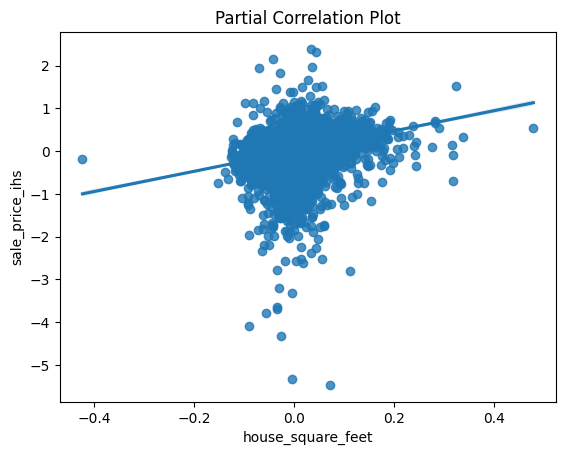

Partial R^2:  0.004130820283237191


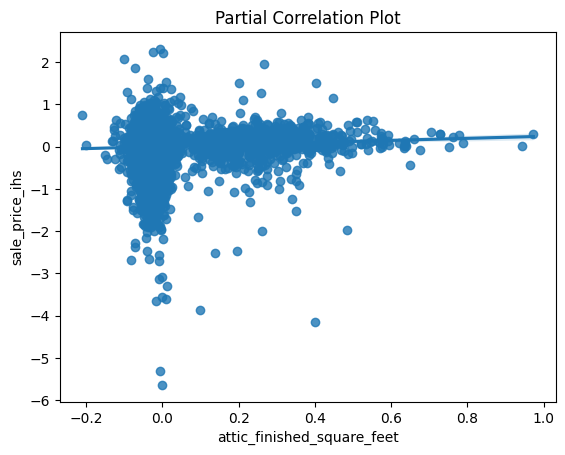

Partial R^2:  0.03763881366888955


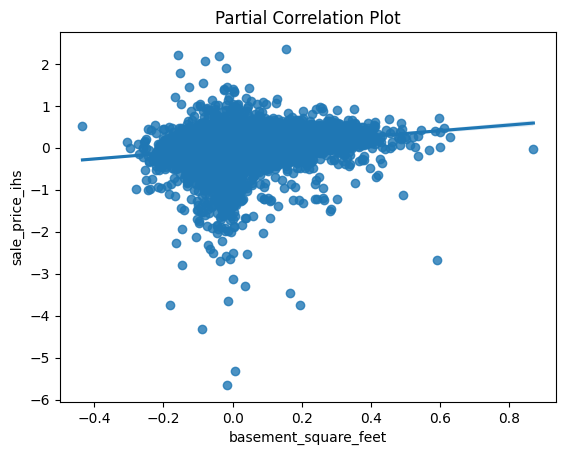

Partial R^2:  0.008902972771619888


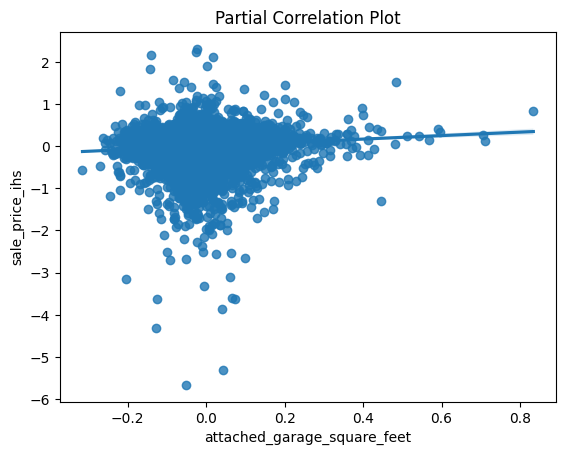

Partial R^2:  0.003261896023332378


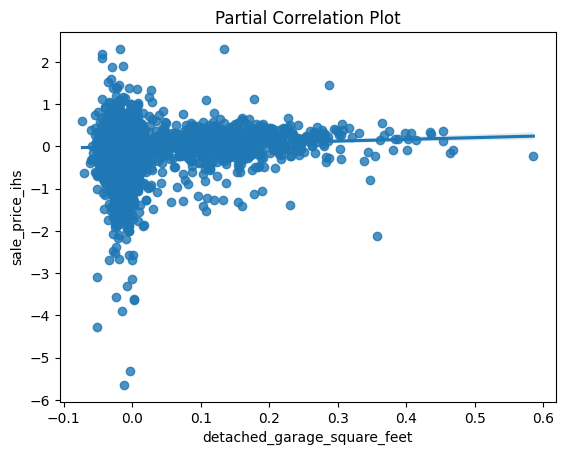

Partial R^2:  0.0019297847340584706


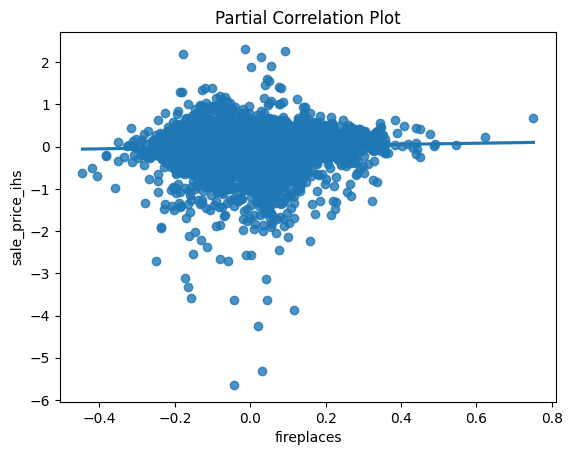

Partial R^2:  0.002050140008046375


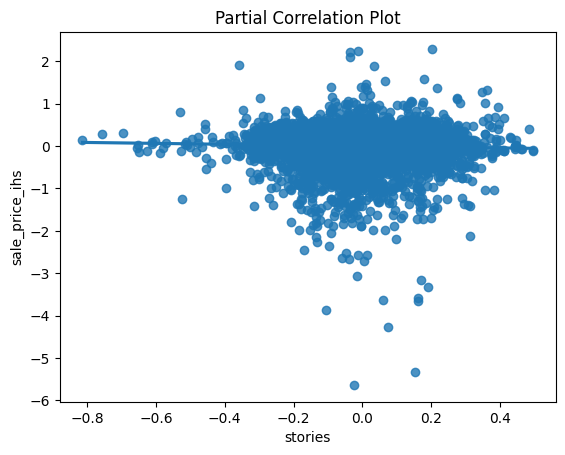

Partial R^2:  0.0009875168641354515


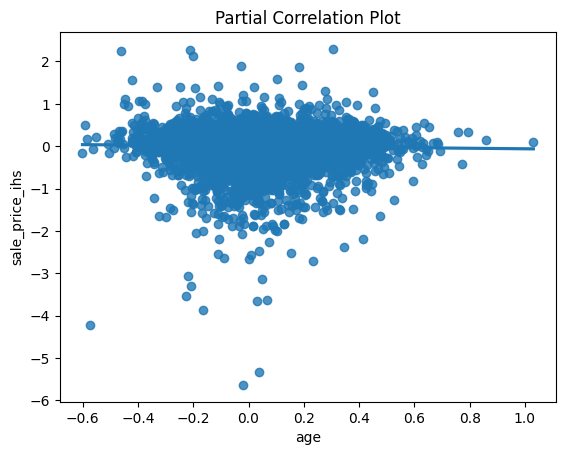

Partial R^2:  0.003352591173830022


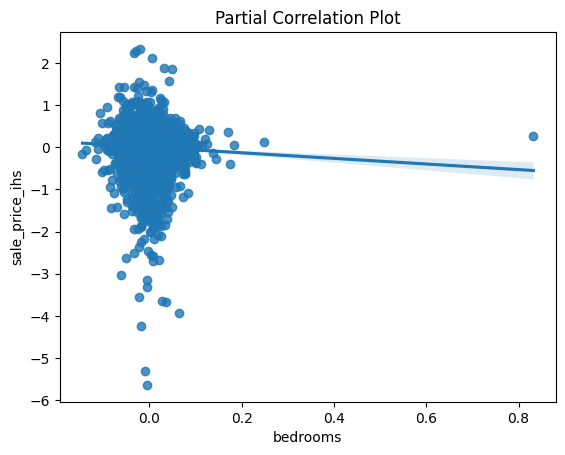

Partial R^2:  0.0032768579973256884


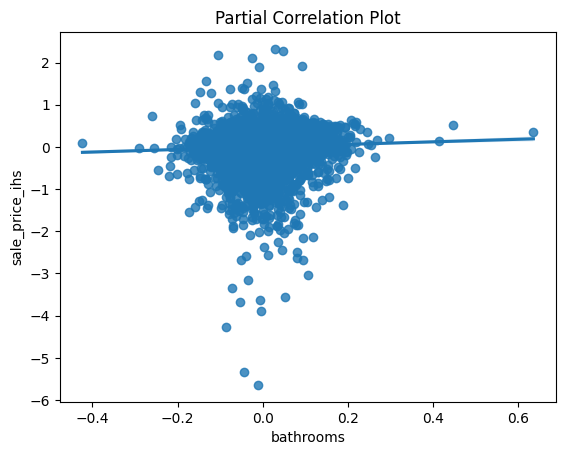

Partial R^2:  0.017314252745050385


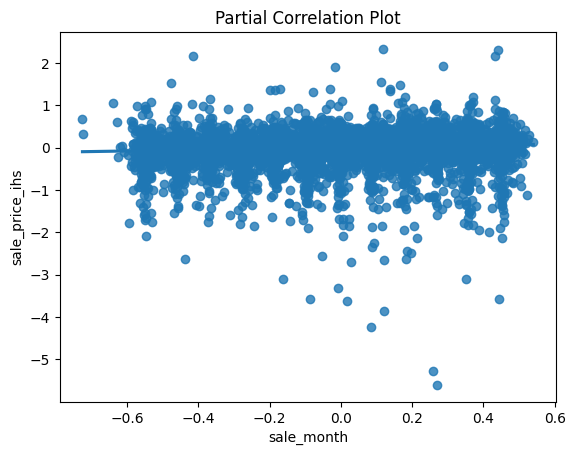

In [52]:
# 5: Partial Correlation Plots for Numeric Variables

num_cols = X_n.columns.tolist()
for var in num_cols:
  x_k = X_train[var]
  X_mk = X_train.drop(var,axis=1)

  reg_y = LinearRegression().fit(X_mk, y_train)
  r_y = y_train - reg_y.predict(X_mk)
  reg_k = LinearRegression().fit(X_mk, x_k)
  r_x = x_k - reg_k.predict(X_mk)

  reg = LinearRegression().fit(r_x.to_numpy().reshape(-1, 1),r_y.to_numpy())
  print('Partial R^2: ', reg.score(r_x.to_numpy().reshape(-1, 1),r_y.to_numpy()) )
  sns.regplot(y=r_y, x=r_x).set(title='Partial Correlation Plot')
  plt.show()

I do not notice any significant non-linearities. While there are some that are very weakly linear, there are not noticeable curves in any of the correlation plots. The two plots that

In [64]:
# 6: Complex Model

df['house_square_feet_ihs'] = np.arcsinh(df['house_square_feet'])
df['attic_sqft_ihs'] = np.arcsinh(df['attic_finished_square_feet'])
df['detached_garage_sqft_ihs'] = np.arcsinh(df['detached_garage_square_feet'])
df['house_sqft_bath_interaction'] = df['house_square_feet'] * df['bathrooms']
df['house_sqft_bed_interaction'] = df['house_square_feet'] * df['bedrooms']
df['house_attic_sqft_interaction'] = df['house_square_feet'] * df['attic_finished_square_feet']
df['house_basement_sqft_interaction'] = df['house_square_feet'] * df['basement_square_feet']

df['has_waterfront'] = (df['waterfront_type'] != 'None').astype(int)
df['house_sqft_water_interaction'] = df['house_square_feet'] * df['has_waterfront']


num_var_new = ['house_square_feet_ihs', 'attic_sqft_ihs', 'basement_square_feet',
               'attached_garage_square_feet', 'detached_garage_sqft_ihs', 'fireplaces',
               'stories', 'age_ihs', 'bedrooms', 'bathrooms', 'sale_month',
               'house_sqft_bath_interaction', 'house_sqft_bed_interaction',
               'house_attic_sqft_interaction', 'house_basement_sqft_interaction',
               'house_sqft_water_interaction']

X_n_new = df[num_var_new].apply(minmax, axis=0)
dummies = pd.get_dummies(df[cat_var], drop_first=True, dtype=int)

X_new = pd.concat([X_n_new, dummies],axis=1)
X.columns = X.columns.astype(str)
y = df['sale_price_ihs']

X_train1, X_test1, y_train1, y_test1 = train_test_split(X_new, y,
                                                    test_size=.2,
                                                    random_state=65)

model_complex = LinearRegression().fit(X_train1, y_train1)
m4 = evaluate_model(model_complex, X_train1, X_test1, y_train1, y_test1)
print('Complex Model Results \n')
print('Train RMSE:', m4[0], '\n')
print('Test RMSE:', m4[1], '\n')
print('Train R2:', m4[2], '\n')
print('Test R2:', m4[3], '\n')


Complex Model Results 

Train RMSE: 0.30490613045432946 

Test RMSE: 0.28880323598867647 

Train R2: 0.4918858952195071 

Test R2: 0.5280887070467915 



The complex model I built performs slightly worse than the simple model with both numeric and categorical variables included. For the complex model, the Test R2 value is slightly lower and the Test RMSE is slightly higher than the Test R2 and RMSE values for the simple model with all variables.

 6: Summary of results from 1 to 6


 Have you learned anything about overfitting and underfitting, or model selection?

In [55]:
# 7: Lasso

from sklearn.linear_model import LassoCV

lasso = LassoCV(random_state=65).fit(X_train, y_train)

coef = pd.Series(lasso.coef_, index=X_train.columns)

selected_features = coef[coef != 0]

print('Selected Features of Simple Model: \n', selected_features, '\n')

y_train_pred = lasso.predict(X_train)
y_test_pred = lasso.predict(X_test)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print('Lasso Results of Simple Model \n')
print('Train RMSE:', train_rmse, '\n')
print('Test RMSE:', test_rmse, '\n')
print('Train R2:', train_r2, '\n')
print('Test R2:', test_r2, '\n')


from sklearn.linear_model import LassoCV

lasso1 = LassoCV(random_state=65).fit(X_train1, y_train1)

coef1 = pd.Series(lasso1.coef_, index=X_train1.columns)

selected_features1 = coef1[coef1 != 0]

print('Selected Features of Complex Model: \n', selected_features1, '\n')

y_train_pred1 = lasso1.predict(X_train1)
y_test_pred1 = lasso1.predict(X_test1)

train_rmse1 = np.sqrt(mean_squared_error(y_train1, y_train_pred1))
test_rmse1 = np.sqrt(mean_squared_error(y_test1, y_test_pred1))

train_r21 = r2_score(y_train1, y_train_pred1)
test_r21 = r2_score(y_test1, y_test_pred1)

print('Lasso Results of Complex Model \n')
print('Train RMSE:', train_rmse1, '\n')
print('Test RMSE:', test_rmse1, '\n')
print('Train R2:', train_r21, '\n')
print('Test R2:', test_r21, '\n')

Selected Features of Simple Model: 
 house_square_feet              2.347528
attic_finished_square_feet     0.229239
basement_square_feet           0.675747
attached_garage_square_feet    0.402940
detached_garage_square_feet    0.380902
fireplaces                     0.135015
stories                       -0.105481
age                           -0.062946
bedrooms                      -0.571084
bathrooms                      0.290631
sale_month                     0.135338
0                              0.396856
1                             -0.420174
2                              0.640888
3                             -0.009868
4                              0.161068
5                              0.291898
6                              0.240216
7                              0.108123
8                              0.129907
9                              0.163641
10                             0.069726
11                             0.454242
12                            -0.018112
13 